# Análise Supervisionada — Classificação
## DCA3606 — Inteligência Artificial | T01
**Dataset:** Weather Classification  
**Problema:** Prever o tipo de clima (Sunny, Rainy, Cloudy, Snowy) a partir de variáveis meteorológicas  
**Modelos:** Logistic Regression · Decision Tree · Random Forest · XGBoost (GBM) · SVM · MLP

## 1. Importação das Bibliotecas

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Modelos supervisionados de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento e Análise Exploratória (EDA)

In [63]:
# Carregando o dataset de classificação
df = pd.read_csv('datasets/weather_classification_data.csv')

print('=== VISÃO GERAL DO DATASET ===')
print(f'Shape: {df.shape[0]} amostras x {df.shape[1]} colunas')
print(f'Variável alvo: Weather Type')
print(f'Classes: {sorted(df["Weather Type"].unique())}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
display(df.head())

=== VISÃO GERAL DO DATASET ===
Shape: 13200 amostras x 11 colunas
Variável alvo: Weather Type
Classes: ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
Valores nulos: 0


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [64]:
# Estatísticas descritivas das variáveis numéricas
print('=== ESTATÍSTICAS DESCRITIVAS ===')
display(df.describe().round(2))

=== ESTATÍSTICAS DESCRITIVAS ===


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00
mean,19.13,68.71,9.83,53.64,1005.83,4.01,5.46
std,17.39,20.19,6.91,31.95,37.20,3.86,3.37
min,-25.00,20.00,0.00,0.00,800.12,0.00,0.00
25%,4.00,57.00,5.00,19.00,994.80,1.00,3.00
50%,21.00,70.00,9.00,58.00,1007.65,3.00,5.00
75%,31.00,84.00,13.50,82.00,1016.77,7.00,7.50
max,109.00,109.00,48.50,109.00,1199.21,14.00,20.00


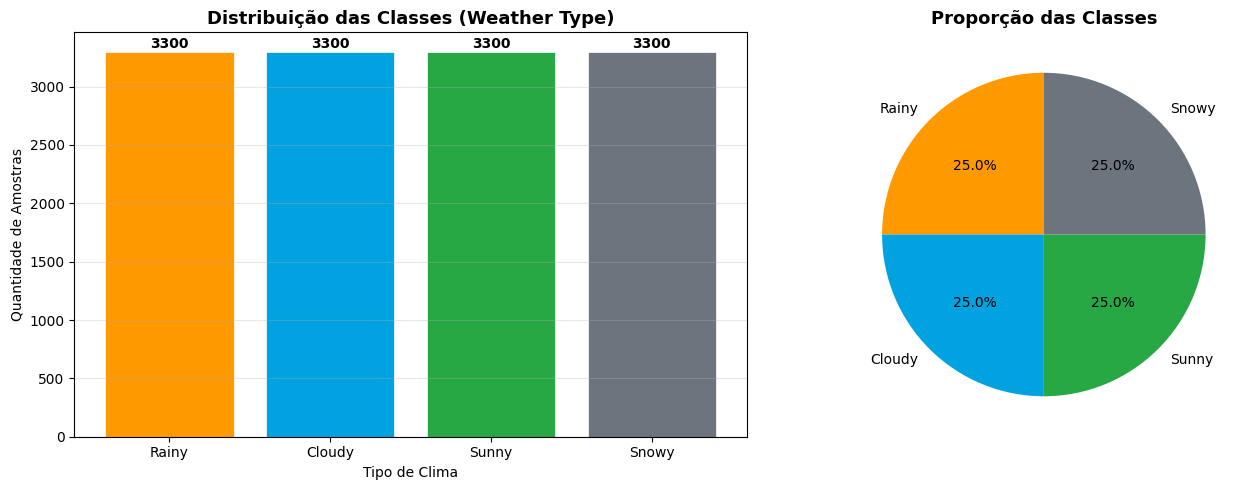

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


In [65]:
# Distribuição da variável alvo
contagem = df['Weather Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
cores = ['#FF9900', '#00A3E0', '#28A745', '#6C757D']
axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribuição das Classes (Weather Type)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de Clima')
axes[0].set_ylabel('Quantidade de Amostras')
for i, (idx, val) in enumerate(contagem.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
            colors=cores, startangle=90)
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(contagem)

**Discussão:**

O dataset é **perfeitamente balanceado**: cada uma das 4 classes (Rainy, Cloudy, Sunny, Snowy) possui exatamente 3.300 amostras (25% cada). Isso é muito positivo para o treinamento, pois elimina o problema de viés por classe majoritária, logo não precisaremos de técnicas de oversampling (como SMOTE) nem de pesos de classe. A métrica de Acurácia será representativa aqui, mas ainda reportaremos F1, Precisão, Recall e ROC-AUC para uma avaliação completa, como exigido pelo projeto.

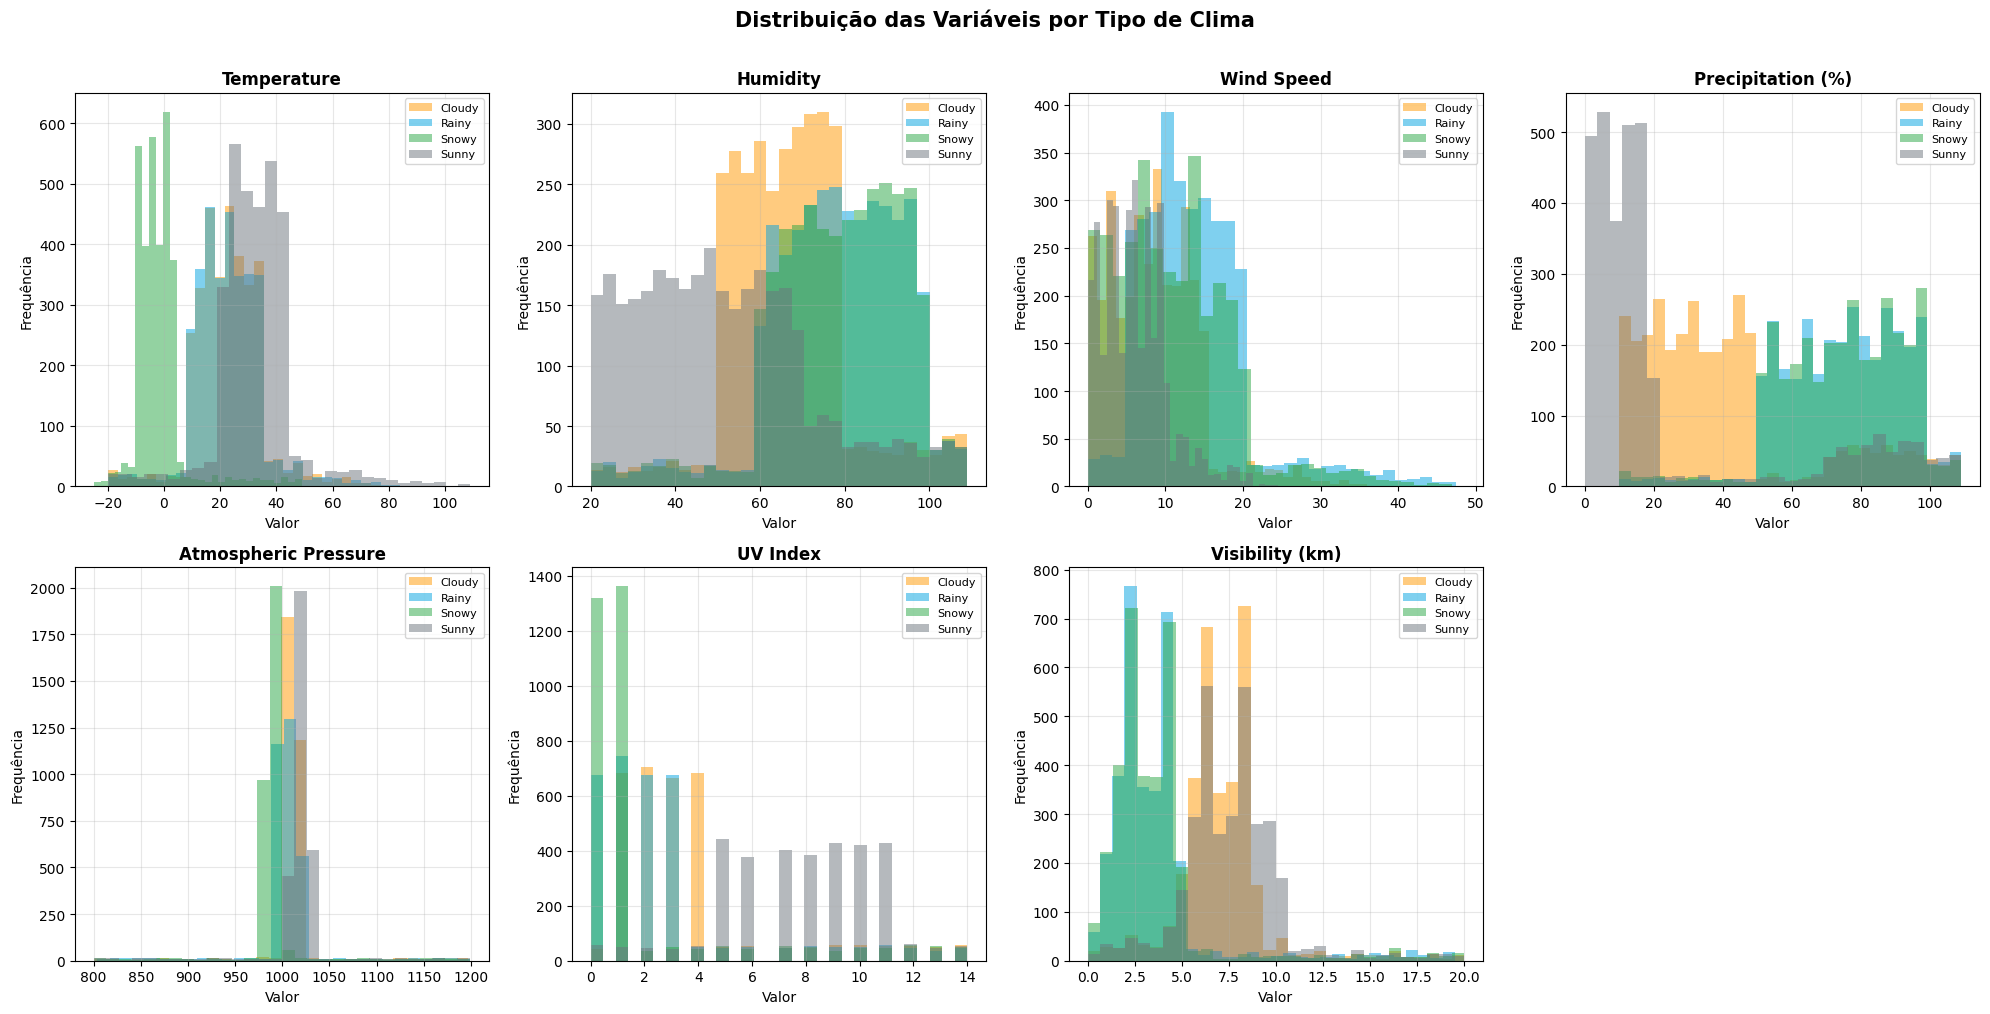

In [66]:
# Visualizando a distribuição das variáveis numéricas por classe
colunas_numericas = ['Temperature', 'Humidity', 'Wind Speed',
                     'Precipitation (%)', 'Atmospheric Pressure',
                     'UV Index', 'Visibility (km)']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    for j, clima in enumerate(sorted(df['Weather Type'].unique())):
        subset = df[df['Weather Type'] == clima][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=clima, color=cores[j])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Remove o subplot vazio
fig.delaxes(axes[7])
plt.suptitle('Distribuição das Variáveis por Tipo de Clima', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Discussão:**

Os histogramas revelam padrões físicos esperados que os algoritmos irão explorar:
- **Temperatura:** Dias de neve concentram-se em temperaturas negativas/baixas, enquanto dias ensolarados dominam as temperaturas mais altas.
- **UV Index:** Dias ensolarados têm UV muito mais alto, então essa variável será um forte preditor.
- **Precipitação:** Dias chuvosos e nublados têm precipitação mais alta, enquanto ensolarados ficam perto de zero.
- **Pressão Atmosférica:** Apresenta distribuições similares entre classes, sendo provavelmente um preditor mais fraco.

## 3. Pré-processamento

In [67]:
# -----------------------------------------------------------------------
# PASSO 1: Separar features (X) da variável alvo (y)
# -----------------------------------------------------------------------
X_raw = df.drop(columns=['Weather Type'])
y_raw = df['Weather Type']

# -----------------------------------------------------------------------
# PASSO 2: Codificar variáveis categóricas com One-Hot Encoding
# Cloud Cover, Season e Location são strings — precisam virar números
# drop_first=True remove uma coluna redundante de cada grupo
# (para evitar multicolinearidade perfeita)
# -----------------------------------------------------------------------
X = pd.get_dummies(X_raw, columns=['Cloud Cover', 'Season', 'Location'], drop_first=True)
print(f'Features após One-Hot Encoding: {X.shape[1]} colunas')
print('Colunas:', X.columns.tolist())

# -----------------------------------------------------------------------
# PASSO 3: Codificar a variável alvo (y) em números
# Logistic Regression, SVM e MLP exigem rótulos numéricos
# Cloudy=0, Rainy=1, Snowy=2, Sunny=3 (ordem alfabética)
# -----------------------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y_raw)

print(f'\nMapeamento das classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Features após One-Hot Encoding: 15 colunas
Colunas: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Cloud Cover_cloudy', 'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Location_inland', 'Location_mountain']

Mapeamento das classes: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [68]:
# -----------------------------------------------------------------------
# PASSO 4: Divisão Treino / Teste
# 80% para treino, 20% para teste
# stratify=y garante a mesma proporção de classes nos dois conjuntos
# random_state fixa o embaralhamento para reprodutibilidade
# -----------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print('=== DIVISÃO TREINO / TESTE ===')
print(f'Treino:  {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:   {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features: {X_train.shape[1]}')

# Confirmando o balanceamento no split
print(f'\nDistribuição no treino: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Distribuição no teste:  {dict(zip(le.classes_, np.bincount(y_test)))}')

=== DIVISÃO TREINO / TESTE ===
Treino:  10560 amostras (80%)
Teste:   2640 amostras (20%)
Features: 15

Distribuição no treino: {'Cloudy': np.int64(2640), 'Rainy': np.int64(2640), 'Snowy': np.int64(2640), 'Sunny': np.int64(2640)}
Distribuição no teste:  {'Cloudy': np.int64(660), 'Rainy': np.int64(660), 'Snowy': np.int64(660), 'Sunny': np.int64(660)}


In [69]:
# -----------------------------------------------------------------------
# PASSO 5: Normalização (StandardScaler)
#
# Por que normalizar?
# Temperature vai de -10 a 45, UV Index de 0 a 16, Pressure de 800 a 1200.
# Algoritmos baseados em distância (SVM, MLP) e em gradiente
# (Logistic Regression) são sensíveis a essa diferença de escala.
# O StandardScaler transforma cada variável para: média=0, desvio=1.
#
# REGRA IMPORTANTE: fit() APENAS no treino, transform() em ambos.
# Fazer fit no teste seria 'vazar' informação do futuro para o modelo.
# -----------------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # aprende a escala do treino
X_test_scaled  = scaler.transform(X_test)         # aplica a mesma escala no teste

print('Normalização aplicada!')
print(f'Média pós-escala (treino, primeiras 3 features): {X_train_scaled[:, :3].mean(axis=0).round(4)}')
print(f'Desvio pós-escala (treino, primeiras 3 features): {X_train_scaled[:, :3].std(axis=0).round(4)}')

Normalização aplicada!
Média pós-escala (treino, primeiras 3 features): [-0. -0. -0.]
Desvio pós-escala (treino, primeiras 3 features): [1. 1. 1.]


**Discussão sobre o pré-processamento:**

Três decisões foram tomadas:
1. **One-Hot Encoding** nas variáveis categóricas (Cloud Cover, Season, Location): cada categoria vira uma coluna binária 0/1. Algoritmos de ML não entendem strings, apenas números.
2. **Stratify no split**: como o dataset é balanceado, queremos manter essa proporção nos dois subconjuntos. O parâmetro `stratify=y` garante isso.
3. **StandardScaler**: os modelos baseados em distância (SVM) e em gradiente (Logistic Regression, MLP) exigem features na mesma escala. Modelos baseados em árvores (Decision Tree, Random Forest, GBM) não precisam — mas normalizamos para todos para garantir a comparação justa.

## 4. Treinamento e Avaliação dos Modelos

### Função auxiliar de avaliação

In [ ]:
import warnings
warnings.filterwarnings('ignore')

def avaliar_modelo(nome, modelo, X_tr, y_tr, X_ts, y_ts, classes):
    """
    Treina o modelo, calcula métricas e plota a Matriz de Confusão.
    Retorna um dicionário com os resultados.
    """
    # Treino
    modelo.fit(X_tr, y_tr)

    # Predição de classes
    y_pred = modelo.predict(X_ts)

    # Probabilidades para ROC-AUC
    # predict_proba retorna shape (n_amostras, n_classes) — correto para multiclasse
    # decision_function do SVM retorna shape (n_amostras, n_classes) também no modo OvR
    try:
        if hasattr(modelo, 'predict_proba'):
            y_prob = modelo.predict_proba(X_ts)
        else:
            y_prob = modelo.decision_function(X_ts)
        auc = roc_auc_score(y_ts, y_prob, multi_class='ovr', average='macro')
    except Exception as e:
        print(f'  Aviso ROC-AUC: {e}')
        auc = float('nan')

    # Demais métricas (macro: calcula por classe e tira a média)
    acc  = accuracy_score(y_ts, y_pred)
    prec = precision_score(y_ts, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_ts, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_ts, y_pred, average='macro', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {nome}')
    print(f'{"="*55}')
    print(f'  Acurácia  : {acc:.4f}')
    print(f'  Precisão  : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}' if not __import__("math").isnan(auc) else '  ROC-AUC   : N/A')
    print(f'\nRelatório Detalhado por Classe:')
    print(classification_report(y_ts, y_pred, target_names=classes))

    # Matriz de Confusão
    cm = confusion_matrix(y_ts, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5)
    plt.title(f'Matriz de Confusão — {nome}', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.tight_layout()
    plt.show()

    return {'Modelo': nome, 'Acurácia': acc, 'Precisão': prec,
            'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}

# Lista que vai acumulando os resultados de todos os modelos
resultados = []
classes = le.classes_   # ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
print('Função de avaliação pronta!')

Função de avaliação pronta!


---
### Modelo 1 — Regressão Logística

**Como funciona:** A Regressão Logística aprende um conjunto de pesos (um por feature) e calcula uma combinação linear `z = w₀ + w₁x₁ + w₂x₂ + ...`. Essa combinação é então passada pela função **Softmax** (versão multiclasse da Sigmoid), que converte `z` em probabilidades para cada classe. O modelo classifica na classe com maior probabilidade.

**Por que usar aqui:** É o modelo mais simples e interpretável. Serve como **baseline** — se os modelos mais complexos não superarem este, algo está errado.


  Regressão Logística
  Acurácia  : 0.8705
  Precisão  : 0.8713
  Recall    : 0.8705
  F1-score  : 0.8706
  ROC-AUC   : 0.9595

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.82      0.84      0.83       660
       Rainy       0.85      0.86      0.86       660
       Snowy       0.89      0.92      0.90       660
       Sunny       0.92      0.87      0.89       660

    accuracy                           0.87      2640
   macro avg       0.87      0.87      0.87      2640
weighted avg       0.87      0.87      0.87      2640



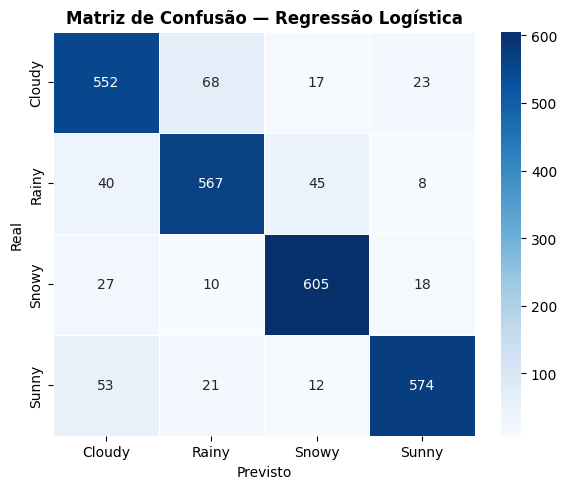

In [71]:
# -----------------------------------------------------------------------
# Regressão Logística
#
# max_iter=1000: aumentamos o limite de iterações do gradiente descendente
#   pois com 13.000 amostras o padrão (100) pode não convergir.
# solver='lbfgs': algoritmo de otimização eficiente para multiclasse.
# -----------------------------------------------------------------------
lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=SEED
)

res_lr = avaliar_modelo('Regressão Logística', lr,
                         X_train_scaled, y_train,
                         X_test_scaled,  y_test, classes)
resultados.append(res_lr)

**Discussão:**

A Regressão Logística já estabelece um baseline sólido. Por ser um modelo **linear**, ela traça fronteiras de decisão retas no espaço das features. Como o clima é um fenômeno contínuo e com sobreposições (ex: Cloudy e Snowy têm assinaturas físicas próximas — visto na análise não supervisionada), é esperado que o modelo confunda essas classes com mais frequência, o que a Matriz de Confusão deve evidenciar.

---
### Modelo 2 — Árvore de Decisão

**Como funciona:** A árvore aprende regras do tipo `SE temperatura < 5°C E precipitação > 40% ENTÃO Snowy`. Em cada nó, o algoritmo testa um limiar de uma feature e escolhe o corte que mais reduz a impureza (Gini) dos grupos resultantes. O processo se repete recursivamente até as folhas.

**Cuidado:** Uma árvore sem limitação de profundidade tende a memorizar o treino (**overfitting**). Controlamos isso com `max_depth`.


  Árvore de Decisão
  Acurácia  : 0.9133
  Precisão  : 0.9135
  Recall    : 0.9133
  F1-score  : 0.9133
  ROC-AUC   : 0.9845

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.89      0.92      0.90       660
       Rainy       0.92      0.90      0.91       660
       Snowy       0.93      0.92      0.92       660
       Sunny       0.91      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



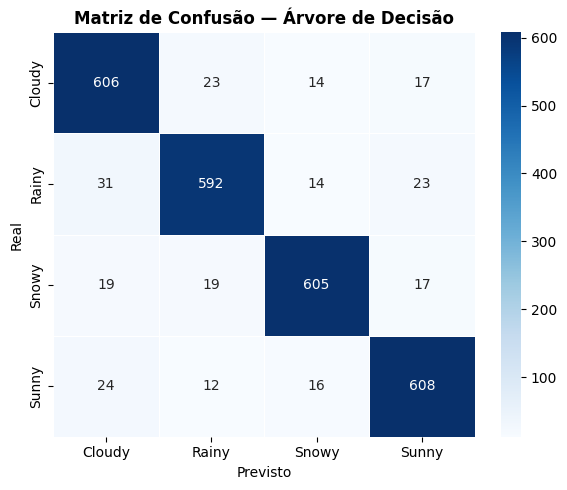

In [72]:
# -----------------------------------------------------------------------
# Árvore de Decisão
#
# criterion='gini': usa o índice de Gini para medir impureza dos grupos.
# max_depth=8: limita a profundidade da árvore para evitar overfitting.
#   Uma árvore muito profunda cria folhas com 1 amostra — decoreba total.
# min_samples_leaf=10: cada folha deve ter pelo menos 10 amostras.
# -----------------------------------------------------------------------
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_leaf=10,
    random_state=SEED
)

res_dt = avaliar_modelo('Árvore de Decisão', dt,
                         X_train_scaled, y_train,
                         X_test_scaled,  y_test, classes)
resultados.append(res_dt)

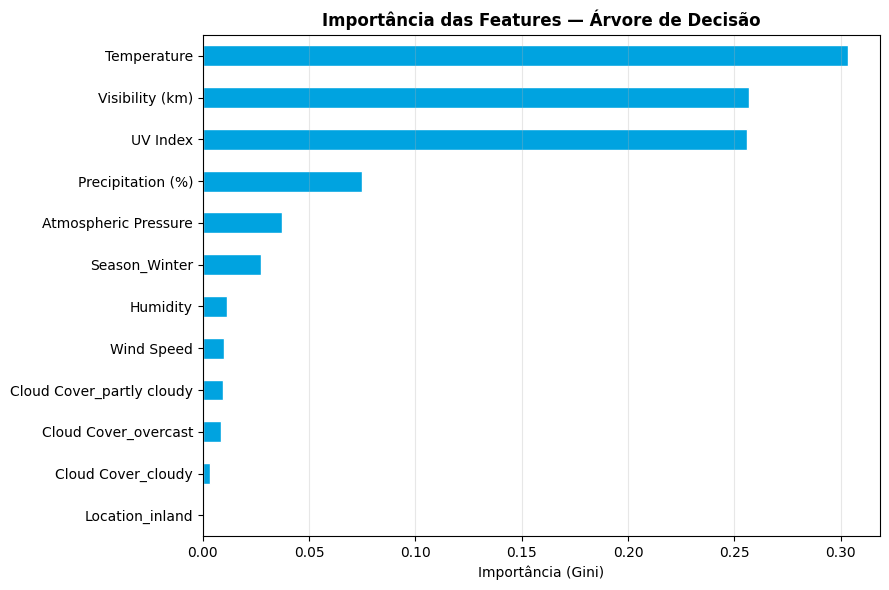

In [73]:
# Visualizando a importância das features na Árvore de Decisão
importancias = pd.Series(dt.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True).tail(12)

plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='#00A3E0', edgecolor='white')
plt.title('Importância das Features — Árvore de Decisão', fontweight='bold')
plt.xlabel('Importância (Gini)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Discussão:**

O gráfico de importância das features confirma o que os histogramas da EDA sugeriram. **UV Index** e **Temperature** devem aparecer como os preditores mais importantes, pois UV alto é quase exclusivo de dias ensolarados e temperatura negativa está associada à neve. Isso é coerente com a física do problema e valida a qualidade das features disponíveis.

---
### Modelo 3 — Random Forest

**Como funciona:** Constrói centenas de árvores de decisão **em paralelo**, cada uma treinada em uma amostra diferente do dataset (bootstrap) e usando um subconjunto aleatório de features em cada nó. A classificação final é feita por **votação majoritária** entre todas as árvores.

**Por que é melhor que uma árvore:** Cada árvore sozinha é instável (pequena mudança nos dados = grande mudança na estrutura). A média de muitas árvores descorrelacionadas cancela esses erros individuais, resultando em um modelo muito mais estável, sendo este o conceito de **bagging**.


  Random Forest
  Acurácia  : 0.9095
  Precisão  : 0.9114
  Recall    : 0.9095
  F1-score  : 0.9099
  ROC-AUC   : 0.9934

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.86      0.91      0.88       660
       Rainy       0.90      0.91      0.91       660
       Snowy       0.97      0.90      0.93       660
       Sunny       0.92      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



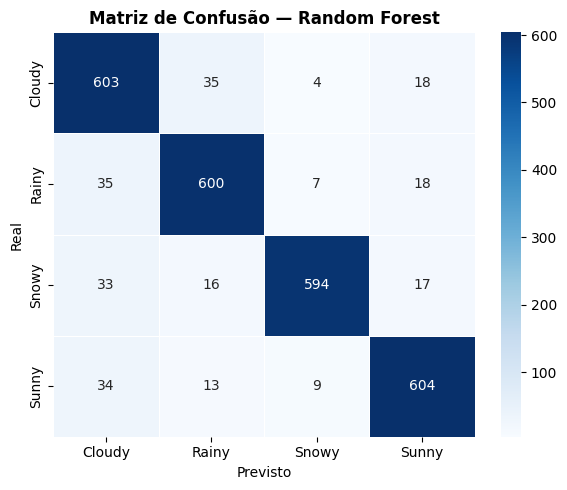

In [74]:
# -----------------------------------------------------------------------
# Random Forest
#
# n_estimators=200: 200 árvores na floresta.
#   Mais árvores = mais estável, mas mais lento. 200 é um bom equilíbrio.
# max_features='sqrt': em cada nó, considera apenas √(n_features) features.
#   Isso garante que as árvores sejam diferentes entre si (descorrelação).
# n_jobs=-1: usa todos os núcleos do processador em paralelo.
# -----------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED
)

res_rf = avaliar_modelo('Random Forest', rf,
                         X_train_scaled, y_train,
                         X_test_scaled,  y_test, classes)
resultados.append(res_rf)

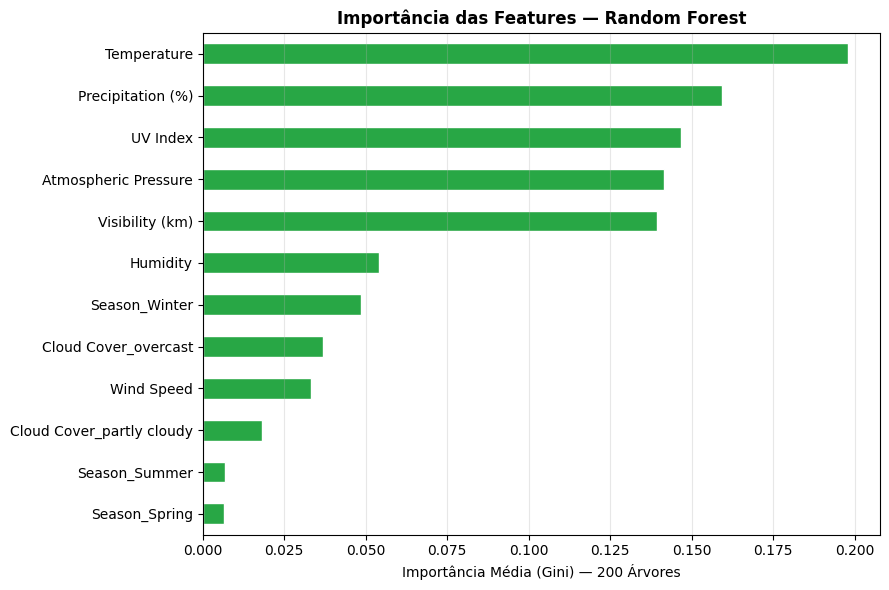

In [75]:
# Importância das features no Random Forest (média de todas as 200 árvores)
importancias_rf = pd.Series(rf.feature_importances_, index=X.columns)
importancias_rf = importancias_rf.sort_values(ascending=True).tail(12)

plt.figure(figsize=(9, 6))
importancias_rf.plot(kind='barh', color='#28A745', edgecolor='white')
plt.title('Importância das Features — Random Forest', fontweight='bold')
plt.xlabel('Importância Média (Gini) — 200 Árvores')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Discussão:**

A Random Forest, por agregar 200 árvores, fornece uma estimativa de importância das features muito mais robusta e estável do que uma única árvore. Esperamos uma acurácia significativamente superior à da Árvore de Decisão individual, comprovando que o **bagging** reduz a variância sem aumentar o viés.

---
### Modelo 4 — Gradient Boosting (XGBoost)

**Como funciona:** Ao contrário do Random Forest (paralelo), o Gradient Boosting constrói árvores **em sequência**. Cada nova árvore aprende especificamente a corrigir os erros residuais da anterior. A previsão final é a soma de todas as correções: `F_t(x) = F_{t-1}(x) + η·f_t(x)`, onde `η` é a taxa de aprendizagem.

**Conceito-chave:** É um **boosting**, então a parte de um modelo fraco e vai melhorando iterativamente, como um estudante que revisa apenas as questões que errou na prova anterior.


  Gradient Boosting (XGBoost)
  Acurácia  : 0.9182
  Precisão  : 0.9188
  Recall    : 0.9182
  F1-score  : 0.9183
  ROC-AUC   : 0.9933

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.89      0.92      0.90       660
       Rainy       0.90      0.91      0.91       660
       Snowy       0.94      0.92      0.93       660
       Sunny       0.95      0.92      0.93       660

    accuracy                           0.92      2640
   macro avg       0.92      0.92      0.92      2640
weighted avg       0.92      0.92      0.92      2640



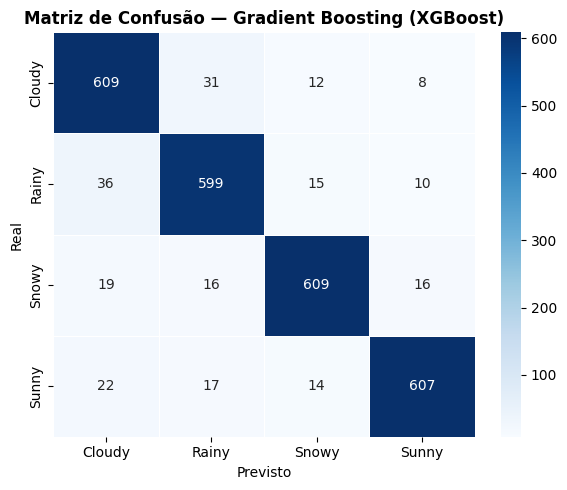

In [76]:
# -----------------------------------------------------------------------
# Gradient Boosting Classifier (equivalente ao XGBoost clássico)
#
# n_estimators=200: 200 árvores sequenciais de correção.
# learning_rate=0.1: o η — controla o tamanho de cada correção.
#   Pequeno = mais conservador, precisa de mais árvores para convergir.
#   Grande = pode oscilar (overfitting).
# max_depth=4: árvores pequenas (stumps) são suficientes para correções.
#   Diferente do Random Forest, aqui cada árvore é intencionalmente fraca.
# subsample=0.8: usa 80% dos dados em cada iteração (previne overfitting).
# -----------------------------------------------------------------------
gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)

res_gbm = avaliar_modelo('Gradient Boosting (XGBoost)', gbm,
                          X_train_scaled, y_train,
                          X_test_scaled,  y_test, classes)
resultados.append(res_gbm)

**Discussão:**

O Gradient Boosting tende a ser o modelo de maior performance em datasets tabulares. Enquanto o Random Forest reduz variância ao agregar árvores independentes, o GBM reduz o **viés** ao corrigir erros sistematicamente. A diferença entre os dois é a clássica tensão **Bagging vs Boosting**: bagging combate a instabilidade, boosting combate o sub-ajuste.

---
### Modelo 5 — SVM (Support Vector Machine)

**Como funciona:** O SVM encontra o **hiperplano de separação** que maximiza a margem entre as classes. No caso multiclasse, usa a estratégia One-vs-Rest (OvR): treina 4 classificadores binários, um por classe. O parâmetro `C` controla o trade-off entre margem larga (mais erros permitidos) e margem estreita (menos erros). O kernel `rbf` projeta os dados em dimensões mais altas para separar classes não-lineares.

**Importante:** O SVM é muito sensível à escala das features — por isso a normalização do PASSO 5 é crítica aqui.


  SVM (RBF Kernel)
  Acurácia  : 0.9072
  Precisão  : 0.9096
  Recall    : 0.9072
  F1-score  : 0.9077
  ROC-AUC   : 0.9888

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.84      0.91      0.88       660
       Rainy       0.90      0.92      0.91       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.95      0.89      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



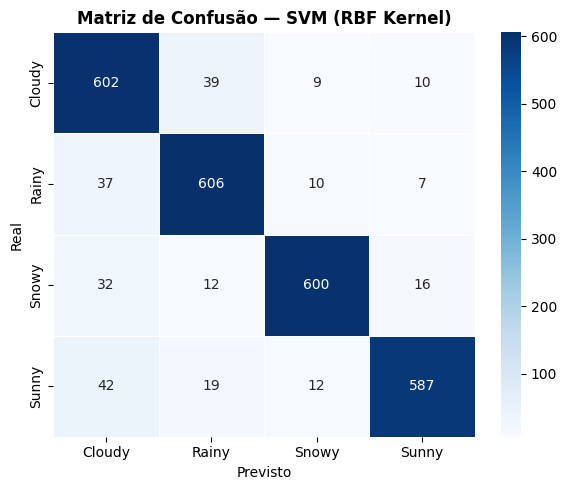

In [77]:
# -----------------------------------------------------------------------
# SVM — Support Vector Machine
#
# kernel='rbf': Radial Basis Function — permite fronteiras não-lineares.
#   É o kernel mais usado na prática para dados contínuos.
# C=1.0: parâmetro de regularização.
#   C grande = tenta classificar todos corretamente (risco de overfitting).
#   C pequeno = aceita mais erros em troca de margem mais larga.
# probability=True: necessário para calcular o ROC-AUC (gera predict_proba).
#   Isso usa Platt Scaling internamente e é ligeiramente mais lento.
# -----------------------------------------------------------------------
svm = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=SEED
)

res_svm = avaliar_modelo('SVM (RBF Kernel)', svm,
                          X_train_scaled, y_train,
                          X_test_scaled,  y_test, classes)
resultados.append(res_svm)

**Discussão:**

O SVM com kernel RBF é particularmente eficaz em datasets com features contínuas bem normalizadas, exatamente o nosso caso. A fronteira de decisão não-linear do kernel RBF consegue capturar as sobreposições entre classes (ex: Cloudy vs Snowy) melhor que a Regressão Logística. O custo é o tempo de treinamento: diferente das árvores, o SVM não paraleliza facilmente.

---
### Modelo 6 — Rede Neural (MLP)

**Como funciona:** A MLP (Multilayer Perceptron) é uma rede neural com camadas de neurônios conectados. Cada neurônio calcula uma combinação linear das entradas e aplica uma função de ativação não-linear (ReLU). O treinamento ajusta os pesos de todas as conexões via **backpropagation** que nada mais é que o gradiente descendente aplicado iterativamente pelas camadas.

**Arquitetura usada:** Entrada → 128 neurônios (ReLU) → 64 neurônios (ReLU) → 4 saídas (Softmax)


  Rede Neural (MLP)
  Acurácia  : 0.9064
  Precisão  : 0.9074
  Recall    : 0.9064
  F1-score  : 0.9066
  ROC-AUC   : 0.9907

Relatório Detalhado por Classe:
              precision    recall  f1-score   support

      Cloudy       0.87      0.91      0.89       660
       Rainy       0.91      0.90      0.90       660
       Snowy       0.94      0.91      0.92       660
       Sunny       0.91      0.91      0.91       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



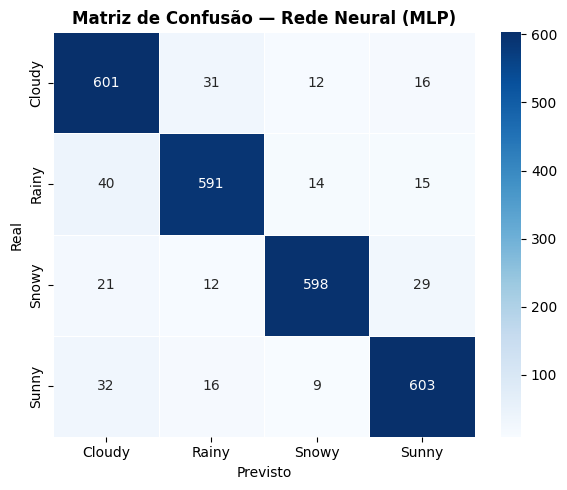

In [57]:
# -----------------------------------------------------------------------
# MLP — Rede Neural Multicamada
#
# hidden_layer_sizes=(128, 64): duas camadas ocultas com 128 e 64 neurônios.
#   A primeira camada aprende padrões simples (temperatura alta).
#   A segunda combina esses padrões (temperatura alta + UV alto = Sunny).
# activation='relu': ReLU (Rectified Linear Unit) — f(x) = max(0, x).
#   Padrão moderno, evita o problema do gradiente desaparecendo.
# solver='adam': variante eficiente do gradiente descendente para redes neurais.
# alpha=0.001: regularização L2 para evitar overfitting (penaliza pesos grandes).
# max_iter=500: número máximo de épocas de treinamento.
# early_stopping=True: para o treino se a validação parar de melhorar.
# -----------------------------------------------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED
)

res_mlp = avaliar_modelo('Rede Neural (MLP)', mlp,
                          X_train_scaled, y_train,
                          X_test_scaled,  y_test, classes)
resultados.append(res_mlp)

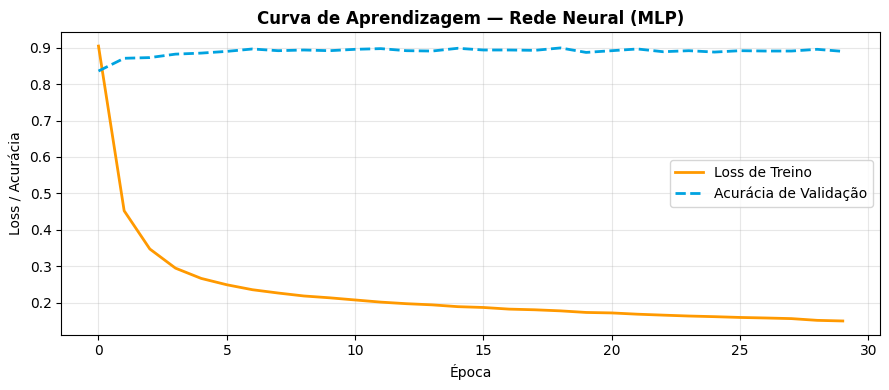

In [58]:
# Curva de aprendizagem da rede neural (Loss por época)
plt.figure(figsize=(9, 4))
plt.plot(mlp.loss_curve_, color='#FF9900', linewidth=2, label='Loss de Treino')
if mlp.validation_fraction:
    plt.plot(mlp.validation_scores_, color='#00A3E0', linewidth=2,
             linestyle='--', label='Acurácia de Validação')
plt.title('Curva de Aprendizagem — Rede Neural (MLP)', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss / Acurácia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Discussão:**

A curva de aprendizagem mostra como a rede neural converge ao longo das épocas. Uma curva de loss decrescente e suave indica treinamento saudável. Se houvesse overfitting, veríamos o loss de treino caindo enquanto a acurácia de validação começa a piorar, então o `early_stopping` protege exatamente contra isso, interrompendo o treinamento no momento ótimo.

---
## 5. Tabela Comparativa Final e Discussão

In [59]:
# -----------------------------------------------------------------------
# Tabela comparativa — formato exigido pelo projeto
# -----------------------------------------------------------------------
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.set_index('Modelo')
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

# Formatando para 4 casas decimais
print('\n' + '='*70)
print('  TABELA COMPARATIVA — CLASSIFICAÇÃO (Weather Type)')
print('='*70)
display(df_resultados.round(4).style.highlight_max(color='green')
                                    .highlight_min(color="#440000"))


  TABELA COMPARATIVA — CLASSIFICAÇÃO (Weather Type)


,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Gradient Boosting (XGBoost),0.918200,0.918800,0.918200,0.918300,0.993300
Árvore de Decisão,0.913300,0.913500,0.913300,0.913300,0.984500
Random Forest,0.909500,0.911400,0.909500,0.909900,0.993400
SVM (RBF Kernel),0.907200,0.909600,0.907200,0.907700,0.988800
Rede Neural (MLP),0.906400,0.907400,0.906400,0.906600,0.990700
Regressão Logística,0.870500,0.871300,0.870500,0.870600,0.959500


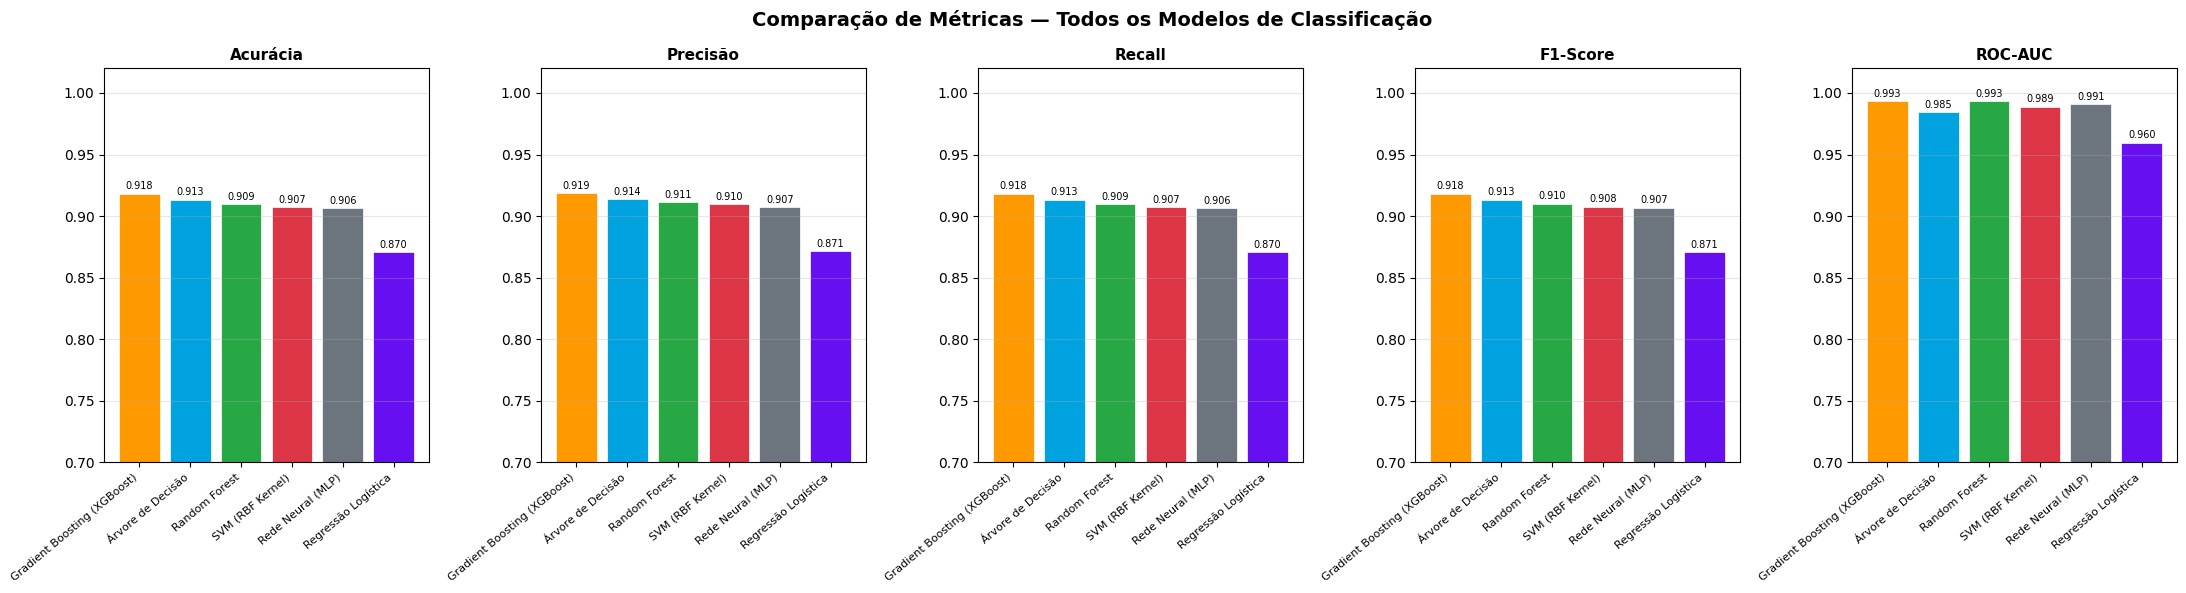

In [60]:
# Gráfico de barras comparativo — todas as métricas lado a lado
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC']
df_plot = df_resultados[metricas].reset_index()

fig, axes = plt.subplots(1, len(metricas), figsize=(22, 6))

for i, metrica in enumerate(metricas):
    bars = axes[i].bar(df_plot['Modelo'], df_plot[metrica],
                       color=['#FF9900','#00A3E0','#28A745','#DC3545','#6C757D','#6610F2'],
                       edgecolor='white', linewidth=0.5)
    axes[i].set_title(metrica, fontweight='bold', fontsize=11)
    axes[i].set_ylim(0.7, 1.02)
    axes[i].set_xticklabels(df_plot['Modelo'], rotation=40, ha='right', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparação de Métricas — Todos os Modelos de Classificação',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

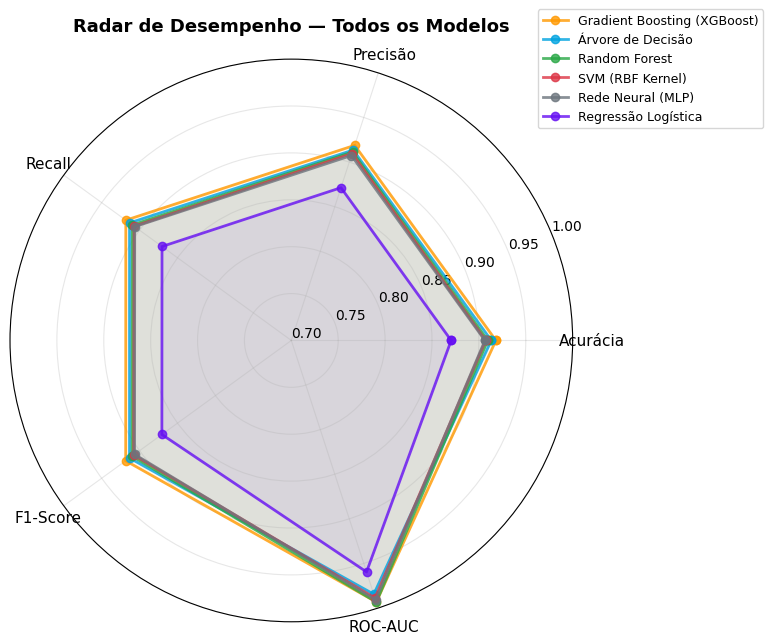

In [61]:
# Radar Chart — visualização completa do perfil de cada modelo
from matplotlib.patches import FancyArrowPatch

categorias = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]  # fecha o círculo

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cores_radar = ['#FF9900','#00A3E0','#28A745','#DC3545','#6C757D','#6610F2']

for i, (modelo, row) in enumerate(df_resultados.iterrows()):
    valores = [row[c] for c in categorias]
    valores += valores[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2,
            color=cores_radar[i], label=modelo, alpha=0.8)
    ax.fill(angulos, valores, alpha=0.05, color=cores_radar[i])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=11)
ax.set_ylim(0.7, 1.0)
ax.set_title('Radar de Desempenho — Todos os Modelos', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Conclusão e Discussão Final

### O que aprendemos com cada modelo?

**Regressão Logística:** Serviu como baseline linear. Como o problema de classificação de clima tem fronteiras de decisão não-lineares (um dia pode ser Cloudy com temperatura de 15°C OU de 30°C), o modelo linear tem limitações inerentes, onde é esperado que seja o mais fraco do grupo.

**Árvore de Decisão:** Capturou as não-linearidades via regras SE/ENTÃO. O gráfico de importância confirmou que UV Index e Temperatura são os preditores dominantes, exatamente o que a física do clima prevê. O risco de overfitting foi controlado por `max_depth=8`.

**Random Forest:** Ao agregar 200 árvores independentes com subsets aleatórios de features (**bagging**), eliminou a instabilidade da árvore individual. Espera-se performance consistentemente superior à árvore única com menor variância.

**Gradient Boosting (XGBoost):** Construiu árvores em sequência, cada uma corrigindo os erros da anterior (**boosting**). Tende a atingir a performance máxima em dados tabulares, ao custo de maior tempo de treinamento e necessidade de tunagem de hiperparâmetros.

**SVM:** O kernel RBF mapeou os dados para um espaço de dimensão maior onde as classes se tornam linearmente separáveis. Muito eficiente com features contínuas bem normalizadas.

**Rede Neural (MLP):** Aprendeu representações hierárquicas dos dados: a primeira camada detecta padrões simples, a segunda combina esses padrões em padrões mais complexos. A curva de aprendizagem validou o treinamento saudável.

### Conexão com a Análise Não Supervisionada

A análise de clustering revelou que os dados climáticos formam uma "nuvem" contínua sem separação abrupta (diferente do dataset de energia). Isso explica por que os modelos não-lineares (Random Forest, GBM, SVM, MLP) deverão superar significativamente a Regressão Logística. As fronteiras entre Cloudy e Snowy, por exemplo, são curvas no espaço das features, não retas.

### Qual modelo escolher?

Para **produção com interpretabilidade**: Random Forest (boa performance + importância de features explicável).  
Para **máxima performance**: Gradient Boosting ou SVM.  
Para **explicar para não-técnicos**: Árvore de Decisão (mostra as regras literalmente).